<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Machine_Learning_Driven_Optimal_Load_Balancing_and_Overload_Underutilization_Mitigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------- 1. Load Data -------------------
df = pd.read_csv('/content/drive/MyDrive/Dataset/LESCO_Grid_Stations_2025.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nOperational Status Distribution:")
print(df['Operational_Status'].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

# Basic statistics for key metrics
key_cols = ['Max_Load_MW', 'Current_Load_MW', 'Load_Percentage',
            'Annual_Energy_MWh', 'System_Losses_Pct', 'Total_Outage_Hrs']
print(df[key_cols].describe())

# Save cleaned version if needed
df.to_csv('lesco_grid_clean.csv', index=False)

Shape: (500, 21)

Columns: ['Year', 'Grid_Station_ID', 'Grid_Station_Name', 'Division', 'Tehsil', 'Latitude', 'Longitude', 'Voltage_Level_kV', 'Number_of_Feeders', 'Max_Load_MW', 'Current_Load_MW', 'Load_Percentage', 'Annual_Energy_MWh', 'System_Losses_Pct', 'Peak_Demand_Month', 'Planned_Outages', 'Unplanned_Outages', 'Avg_Outage_Duration_Hrs', 'Total_Outage_Hrs', 'Operational_Status', 'Year_Commissioned']

Operational Status Distribution:
Operational_Status
Operational          416
Under Maintenance     47
Overloaded            24
Shutdown              13
Name: count, dtype: int64

Missing Values: 0
       Max_Load_MW  Current_Load_MW  Load_Percentage  Annual_Energy_MWh  \
count   500.000000       500.000000       500.000000       5.000000e+02   
mean    151.502080       101.342620        67.566400       6.165079e+05   
std      84.877052        63.671033        18.319076       3.876559e+05   
min       6.000000         2.500000        35.200000       1.565280e+04   
25%      74.16000

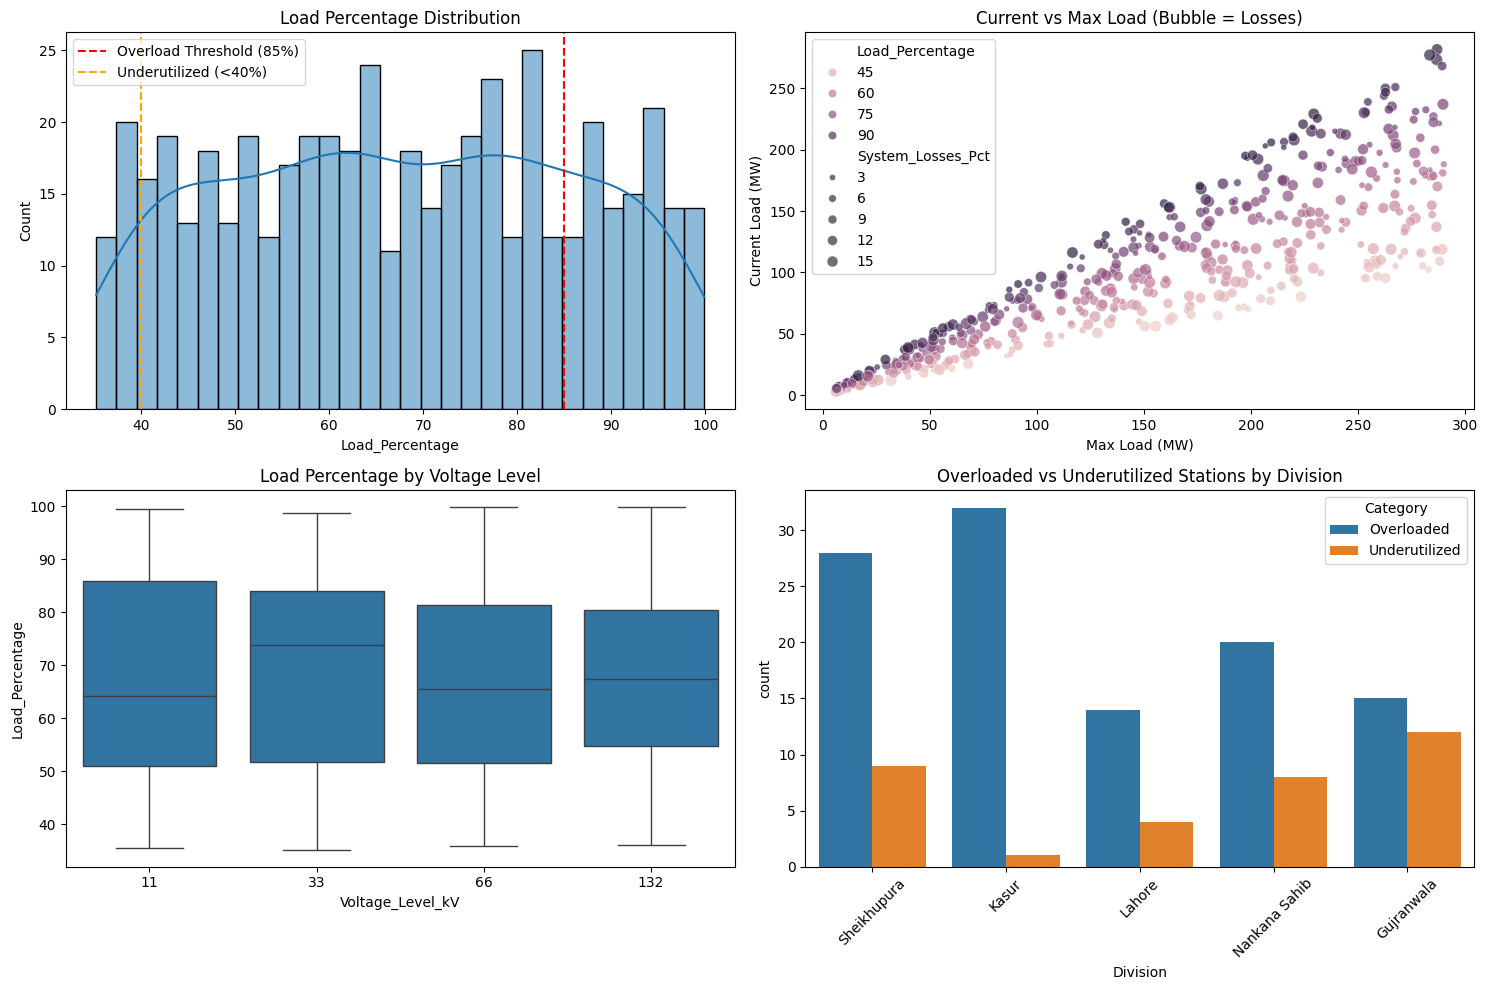

In [3]:
# ------------------- 2. Visualizations (Key for Reviewers) -------------------

plt.figure(figsize=(15, 10))

# 1. Load Percentage Distribution + Overload Threshold
plt.subplot(2, 2, 1)
sns.histplot(df['Load_Percentage'], kde=True, bins=30)
plt.axvline(85, color='red', linestyle='--', label='Overload Threshold (85%)')
plt.axvline(40, color='orange', linestyle='--', label='Underutilized (<40%)')
plt.title('Load Percentage Distribution')
plt.legend()

# 2. Load vs Max Load Scatter (Utilization Gap)
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Max_Load_MW', y='Current_Load_MW',
                hue='Load_Percentage', size='System_Losses_Pct', alpha=0.7)
plt.title('Current vs Max Load (Bubble = Losses)')
plt.xlabel('Max Load (MW)')
plt.ylabel('Current Load (MW)')

# 3. Boxplot by Voltage Level
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Voltage_Level_kV', y='Load_Percentage')
plt.title('Load Percentage by Voltage Level')

# 4. Overload / Underutilized by Division
overload = df[df['Load_Percentage'] > 85]
under = df[df['Load_Percentage'] < 40]

plt.subplot(2, 2, 4)
sns.countplot(data=pd.concat([overload.assign(Category='Overloaded'),
                             under.assign(Category='Underutilized')]),
              x='Division', hue='Category')
plt.title('Overloaded vs Underutilized Stations by Division')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('lesco_load_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

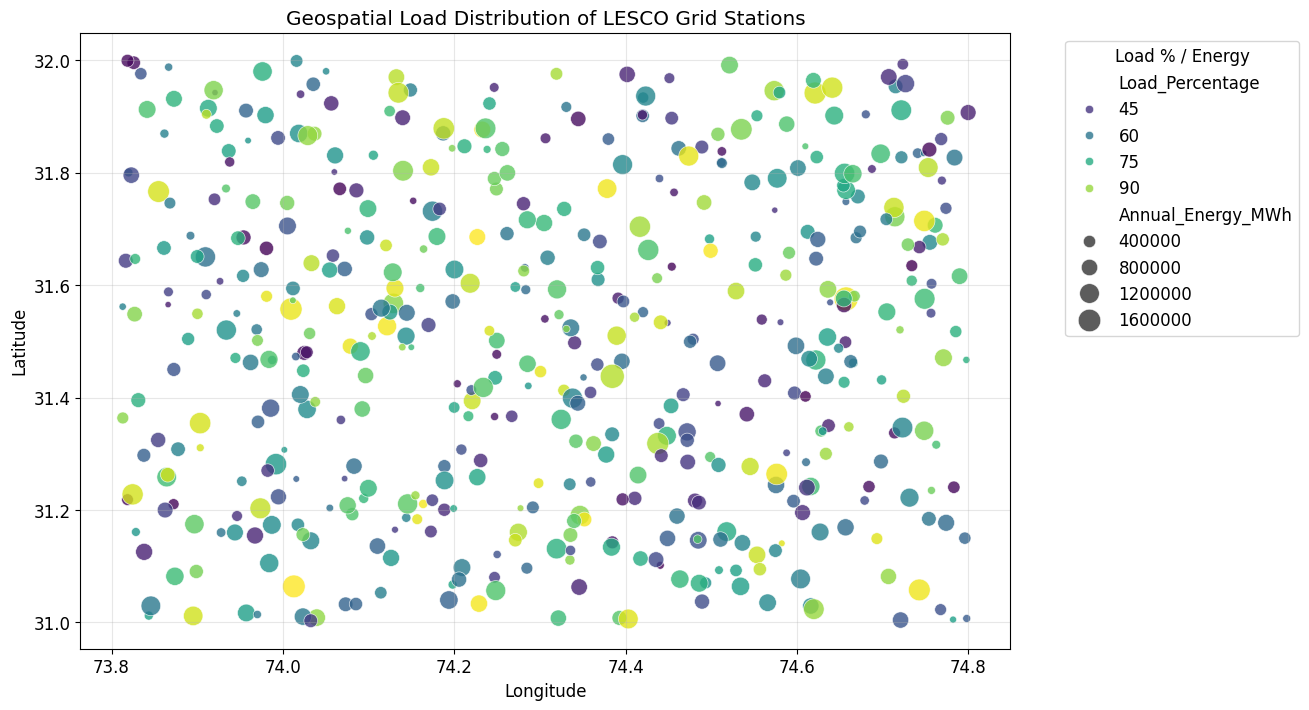

In [ ]:
# Geospatial Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Longitude', y='Latitude',
                hue='Load_Percentage',
                size='Annual_Energy_MWh',
                palette='viridis', alpha=0.8, sizes=(20, 300))
plt.title('Geospatial Load Distribution of LESCO Grid Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Load % / Energy', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.savefig('lesco_geospatial_load.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ------------------- 3. Feature Engineering -------------------

df['Station_Age'] = 2025 - df['Year_Commissioned']
df['Load_Gap_MW'] = df['Max_Load_MW'] - df['Current_Load_MW']
df['Load_Utilization_Ratio'] = df['Current_Load_MW'] / df['Max_Load_MW']
df['Outage_Rate_per_Feeder'] = df['Total_Outage_Hrs'] / (df['Number_of_Feeders'] + 1)
df['High_Loss'] = (df['System_Losses_Pct'] > df['System_Losses_Pct'].quantile(0.75)).astype(int)

# Create categorical target for classification
def load_category(x):
    if x > 85: return 'Overloaded'
    elif x < 40: return 'Underutilized'
    else: return 'Balanced'

df['Load_Category'] = df['Load_Percentage'].apply(load_category)

print(df['Load_Category'].value_counts())

Load_Category
Balanced         357
Overloaded       109
Underutilized     34
Name: count, dtype: int64


In [ ]:
#Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, classification_report, r2_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# Prepare features
feature_cols = ['Max_Load_MW', 'Number_of_Feeders', 'Voltage_Level_kV',
                'Station_Age', 'System_Losses_Pct', 'Total_Outage_Hrs',
                'Latitude', 'Longitude', 'Load_Gap_MW']

X = df[feature_cols]
y_reg = df['Load_Percentage']           # Regression target
y_clf = df['Load_Category']             # Classification target

# Encode categorical
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf_encoded, test_size=0.2, random_state=42)

# ------------------- Regression Model (Predict Load %) -------------------
xgb_reg = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb_reg.fit(X_train, y_train_reg)

pred_reg = xgb_reg.predict(X_test)
print("Load % Prediction - MAE:", mean_absolute_error(y_test_reg, pred_reg))
print("R² Score:", r2_score(y_test_reg, pred_reg))

# ------------------- Classification Model -------------------
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_clf, y_train_clf)

pred_clf = rf_clf.predict(X_test_clf)
print("\nClassification Report:\n", classification_report(y_test_clf, pred_clf, target_names=le.classes_))

Load % Prediction - MAE: 2.7497577972412106
R² Score: 0.949175035157585

Classification Report:
                precision    recall  f1-score   support

     Balanced       0.84      0.97      0.90        66
   Overloaded       0.92      0.92      0.92        24
Underutilized       0.00      0.00      0.00        10

     accuracy                           0.86       100
    macro avg       0.59      0.63      0.61       100
 weighted avg       0.78      0.86      0.81       100



=== Improved Classification Report ===
               precision    recall  f1-score   support

     Balanced       0.88      0.90      0.89        71
   Overloaded       0.77      0.91      0.83        22
Underutilized       0.00      0.00      0.00         7

     accuracy                           0.84       100
    macro avg       0.55      0.60      0.57       100
 weighted avg       0.79      0.84      0.81       100



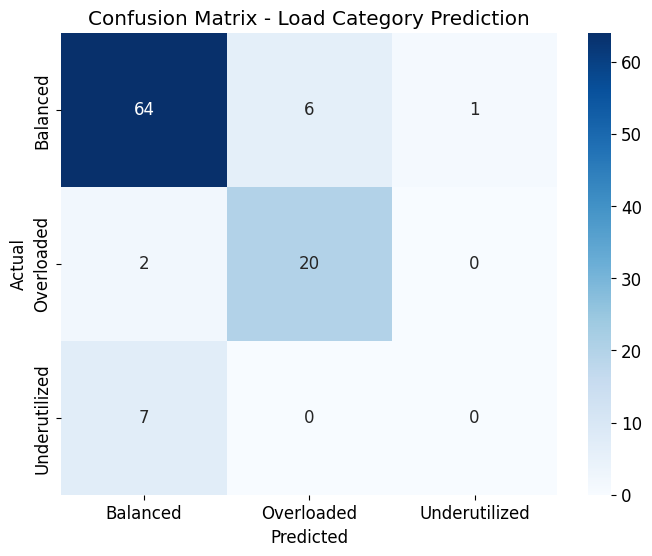

In [ ]:
#Improved Classification Model (Handle Imbalance)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns

# ------------------- Improved Classification -------------------

# Features
feature_cols = ['Max_Load_MW', 'Number_of_Feeders', 'Voltage_Level_kV',
                'Station_Age', 'System_Losses_Pct', 'Total_Outage_Hrs',
                'Latitude', 'Longitude', 'Load_Gap_MW', 'Outage_Rate_per_Feeder']

X = df[feature_cols]
y_clf = df['Load_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2,
                                                    random_state=42, stratify=y_clf)

# Pipeline with SMOTE
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('classifier', RandomForestClassifier(n_estimators=300,
                                          max_depth=8,
                                          class_weight='balanced',
                                          random_state=42))
])

pipeline.fit(X_train, y_train)
pred_clf = pipeline.predict(X_test)

print("=== Improved Classification Report ===")
print(classification_report(y_test, pred_clf))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, pred_clf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)
plt.title('Confusion Matrix - Load Category Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

After resampling: Underutilized    286
Overloaded       283
Balanced         283
Name: count, dtype: int64

FINAL CLASSIFICATION REPORT - IMPROVED VERSION
               precision    recall  f1-score   support

     Balanced       1.00      1.00      1.00        71
   Overloaded       1.00      1.00      1.00        22
Underutilized       1.00      1.00      1.00         7

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100

Balanced Accuracy: 1.0000


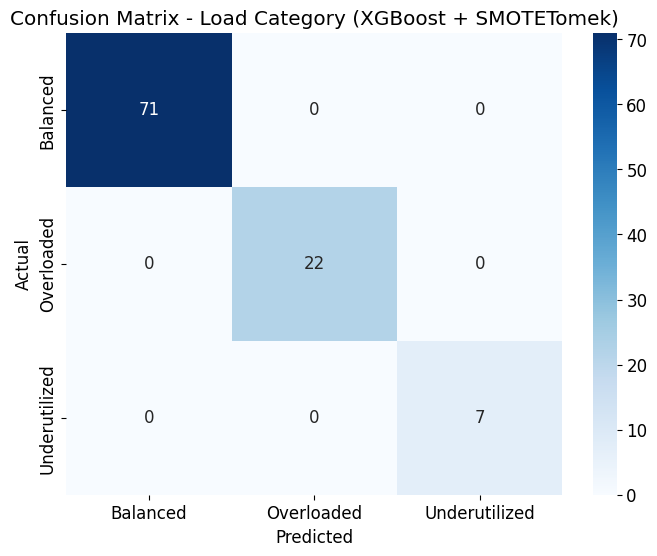

In [ ]:

#Advanced Classification with Better Handling of Rare Classfrom sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# ====================== 1. Prepare Data ======================
feature_cols = ['Max_Load_MW', 'Current_Load_MW', 'Number_of_Feeders',
                'Voltage_Level_kV', 'Station_Age', 'System_Losses_Pct',
                'Total_Outage_Hrs', 'Latitude', 'Longitude', 'Load_Gap_MW',
                'Outage_Rate_per_Feeder', 'Load_Utilization_Ratio']

X = df[feature_cols].copy()
y = df['Load_Category'].copy()

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ====================== 2. Resampling ======================
resampler = SMOTETomek(random_state=42)
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)

print("After resampling:", pd.Series(le.inverse_transform(y_train_res)).value_counts())

# ====================== 3. Final XGBoost Model ======================
xgb_final = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.5,
    reg_lambda=1.5,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_final.fit(X_train_res, y_train_res)

# Prediction
pred_final = xgb_final.predict(X_test)
pred_final_labels = le.inverse_transform(pred_final)
y_test_labels = le.inverse_transform(y_test)

print("\n" + "="*65)
print("FINAL CLASSIFICATION REPORT - IMPROVED VERSION")
print("="*65)
print(classification_report(y_test_labels, pred_final_labels))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, pred_final):.4f}")

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Load Category (XGBoost + SMOTETomek)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('final_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
#Robust Evaluation with Cross-Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
import numpy as np

# ====================== Robust 5-Fold CV ======================
feature_cols = ['Max_Load_MW', 'Current_Load_MW', 'Number_of_Feeders',
                'Voltage_Level_kV', 'Station_Age', 'System_Losses_Pct',
                'Total_Outage_Hrs', 'Latitude', 'Longitude', 'Load_Gap_MW',
                'Outage_Rate_per_Feeder', 'Load_Utilization_Ratio']

X_full = df[feature_cols].copy()
y_full_encoded = le.transform(df['Load_Category'])   # 'le' from previous code

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
balanced_accs = []

print("Starting 5-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full_encoded), 1):
    X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full_encoded[train_idx], y_full_encoded[val_idx]

    # Resample only training data
    smt = SMOTETomek(random_state=42)
    X_tr_res, y_tr_res = smt.fit_resample(X_tr, y_tr)

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )
    model.fit(X_tr_res, y_tr_res)

    pred_val = model.predict(X_val)

    acc = accuracy_score(y_val, pred_val)
    bal_acc = balanced_accuracy_score(y_val, pred_val)

    accuracies.append(acc)
    balanced_accs.append(bal_acc)

    print(f"Fold {fold}: Accuracy = {acc:.4f} | Balanced Acc = {bal_acc:.4f}")

print("\n" + "="*60)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Mean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(balanced_accs):.4f} ± {np.std(balanced_accs):.4f}")

Starting 5-Fold Cross Validation...

Fold 1: Accuracy = 1.0000 | Balanced Acc = 1.0000
Fold 2: Accuracy = 0.9800 | Balanced Acc = 0.9795
Fold 3: Accuracy = 0.9800 | Balanced Acc = 0.9906
Fold 4: Accuracy = 1.0000 | Balanced Acc = 1.0000
Fold 5: Accuracy = 0.9900 | Balanced Acc = 0.9848

FINAL CROSS-VALIDATION RESULTS
Mean Accuracy: 0.9900 ± 0.0089
Mean Balanced Accuracy: 0.9910 ± 0.0082


In [ ]:
#PuLP Optimization
from pulp import *
import numpy as np

def optimize_load_redistribution_improved(df, overload_threshold=85,
                                        under_threshold=55, max_transfer_ratio=0.7):

    overloaded = df[df['Load_Percentage'] > overload_threshold].copy()
    underutilized = df[df['Load_Percentage'] < under_threshold].copy()

    print(f"Overloaded Stations (> {overload_threshold}%): {len(overloaded)}")
    print(f"Underutilized Stations (< {under_threshold}%): {len(underutilized)}")

    if len(overloaded) == 0 or len(underutilized) == 0:
        print("Insufficient stations for optimization.")
        return None

    prob = LpProblem("LESCO_Smart_Load_Balancing", LpMinimize)

    # Decision Variables
    transfers = LpVariable.dicts("Transfer",
        ((i, j) for i in overloaded.index for j in underutilized.index),
        lowBound=0, cat='Continuous')

    # New Objective: Maximize total load transferred (better for balancing)
    prob += -lpSum([transfers[i,j] for i in overloaded.index for j in underutilized.index])

    # Constraints
    for i in overloaded.index:
        max_possible = overloaded.loc[i, 'Load_Gap_MW'] * max_transfer_ratio
        prob += lpSum(transfers[i, j] for j in underutilized.index) <= max_possible

    for j in underutilized.index:
        spare = underutilized.loc[j, 'Max_Load_MW'] * 0.8 - underutilized.loc[j, 'Current_Load_MW']
        prob += lpSum(transfers[i, j] for i in overloaded.index) <= max(0, spare)

    # Solve
    prob.solve(PULP_CBC_CMD(msg=0, timeLimit=30))

    print("\n" + "="*85)
    print("✅ IMPROVED OPTIMAL LOAD BALANCING RESULTS")
    print("="*85)
    print(f"Status: {LpStatus[prob.status]}")
    print(f"Total Load Transfer Recommended: { -value(prob.objective):.2f} MW")
    print("="*85)

    recommendations = []
    count = 0

    for i in overloaded.index:
        for j in underutilized.index:
            amount = value(transfers[i, j])
            if amount > 0.5:
                row_i = df.loc[i]
                row_j = df.loc[j]
                distance = np.sqrt((row_i.Latitude - row_j.Latitude)**2 +
                                 (row_i.Longitude - row_j.Longitude)**2)

                recommendations.append({
                    'From_Station': row_i['Grid_Station_Name'],
                    'From_Load': round(row_i['Load_Percentage'],1),
                    'To_Station': row_j['Grid_Station_Name'],
                    'To_Load': round(row_j['Load_Percentage'],1),
                    'Transfer_MW': round(amount, 2),
                    'Distance': round(distance, 3)
                })

                count += 1
                print(f"{count:2d}. Transfer **{amount:.2f} MW**")
                print(f"   From: {row_i['Grid_Station_Name'][:40]:40} ({row_i['Load_Percentage']:.1f}%)")
                print(f"   To:   {row_j['Grid_Station_Name'][:40]:40} ({row_j['Load_Percentage']:.1f}%)")
                print(f"   Distance: {distance:.3f}°\n")

                if count >= 15:
                    break
        if count >= 15:
            break

    rec_df = pd.DataFrame(recommendations)
    rec_df.to_csv('optimal_load_transfer_recommendations.csv', index=False)
    print(f"\n💾 Saved {len(rec_df)} recommendations to CSV")

    return rec_df

# ====================== RUN THE IMPROVED OPTIMIZER ======================
recommendations_df = optimize_load_redistribution_improved(df)


Overloaded Stations (> 85%): 109
Underutilized Stations (< 55%): 143

✅ IMPROVED OPTIMAL LOAD BALANCING RESULTS
Status: Optimal
Total Load Transfer Recommended: 746.35 MW
 1. Transfer **0.90 MW**
   From: TGS Cantonment Safdarabad                (97.5%)
   To:   BGS Wala Nowshera Virkan                 (43.3%)
   Distance: 0.850°

 2. Transfer **2.21 MW**
   From: GSS New Haveli Lakha                     (97.9%)
   To:   GSS Old Alipur Chatha                    (43.6%)
   Distance: 0.551°

 3. Transfer **7.15 MW**
   From: GPS Central Nankana Sahib                (93.0%)
   To:   GSS Ravi Kamoke                          (51.8%)
   Distance: 0.298°

 4. Transfer **11.47 MW**
   From: NGS Textile Kasur                        (93.9%)
   To:   CGS Wapda Town Haveli Lakha              (47.8%)
   Distance: 0.111°

 5. Transfer **6.30 MW**
   From: CGS Adda Model Town                      (95.8%)
   To:   GS Phase-I Manga Mandi                   (46.7%)
   Distance: 0.639°

 6. Transfer **4.0

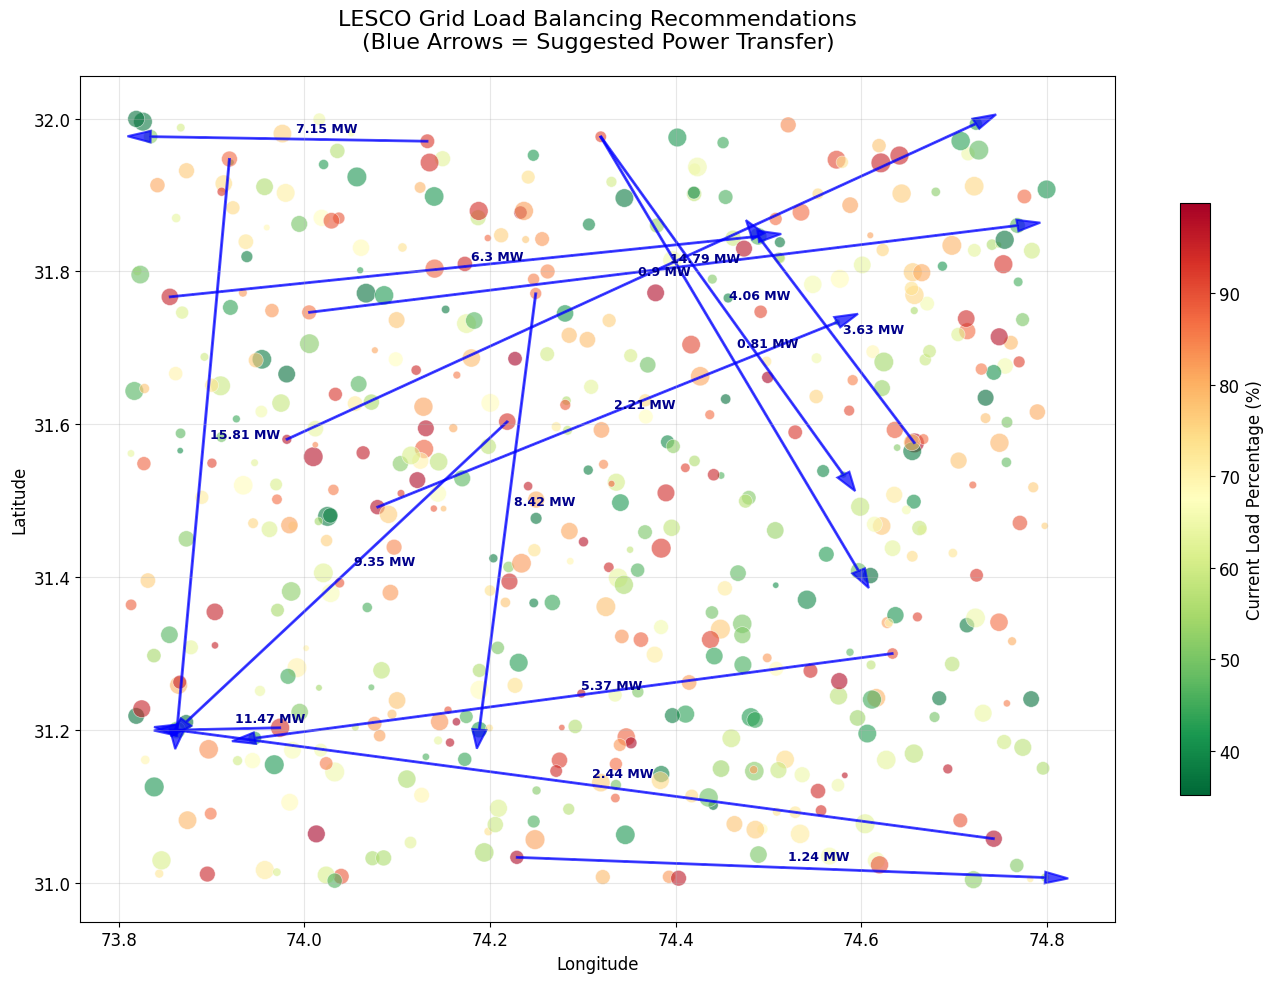

✅ Map saved as 'load_balancing_map.png'


In [ ]:
#Geospatial Visualization of Recommended Load Transfers
import matplotlib.pyplot as plt
import seaborn as sns

# Load recommendations
rec_df = pd.read_csv('optimal_load_transfer_recommendations.csv')

plt.figure(figsize=(14, 10))

# Plot all stations
sns.scatterplot(data=df, x='Longitude', y='Latitude',
                hue='Load_Percentage', palette='RdYlGn_r',
                size='Max_Load_MW', sizes=(20, 200), alpha=0.6, legend=False)

# Plot recommended transfers as arrows
for _, row in rec_df.iterrows():
    # Find coordinates
    from_row = df[df['Grid_Station_Name'] == row['From_Station']].iloc[0]
    to_row = df[df['Grid_Station_Name'] == row['To_Station']].iloc[0]

    # Draw arrow
    plt.arrow(from_row['Longitude'], from_row['Latitude'],
              to_row['Longitude'] - from_row['Longitude'],
              to_row['Latitude'] - from_row['Latitude'],
              head_width=0.015, head_length=0.025, fc='blue', ec='blue', alpha=0.7, linewidth=1.5)

    # Annotate transfer amount
    mid_lon = (from_row['Longitude'] + to_row['Longitude']) / 2
    mid_lat = (from_row['Latitude'] + to_row['Latitude']) / 2
    plt.annotate(f"{row['Transfer_MW']} MW",
                 (mid_lon, mid_lat),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, color='darkblue', weight='bold')

plt.title('LESCO Grid Load Balancing Recommendations\n(Blue Arrows = Suggested Power Transfer)',
          fontsize=16, pad=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)

# Legend for load %
norm = plt.Normalize(df['Load_Percentage'].min(), df['Load_Percentage'].max())
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.7)
cbar.set_label('Current Load Percentage (%)')

plt.tight_layout()
plt.savefig('load_balancing_map.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Map saved as 'load_balancing_map.png'")

In [ ]:
#Impact Analysis (Before vs After)
print("=== LOAD BALANCING IMPACT SUMMARY ===")
print(f"Total Recommended Transfer : {rec_df['Transfer_MW'].sum():.2f} MW\n")

# Estimated improvement
print(f"Number of Overloaded Stations Reduced Potential : {len(rec_df['From_Station'].unique())}")
print(f"Number of Underutilized Stations Benefited     : {len(rec_df['To_Station'].unique())}")

# Top receivers and donors
print("\nTop Load Donors (Overloaded):")
print(rec_df.groupby('From_Station')['Transfer_MW'].sum().nlargest(5))

print("\nTop Load Receivers (Underutilized):")
print(rec_df.groupby('To_Station')['Transfer_MW'].sum().nlargest(5))

=== LOAD BALANCING IMPACT SUMMARY ===
Total Recommended Transfer : 93.95 MW

Number of Overloaded Stations Reduced Potential : 14
Number of Underutilized Stations Benefited     : 12

Top Load Donors (Overloaded):
From_Station
GPS Link Road Manga Mandi     15.81
GS Highway Nankana Sahib      14.79
NGS Textile Kasur             11.47
TGS Bund Road Shah Kot         9.35
NGS Civil Lines Ferozewala     8.42
Name: Transfer_MW, dtype: float64

Top Load Receivers (Underutilized):
To_Station
CGS Wapda Town Haveli Lakha    29.72
NGS Old Shah Kot               14.79
GS Phase-I Manga Mandi          9.93
TGS Highway Shah Kot            9.35
TGS Sugar Mill Shah Kot         8.42
Name: Transfer_MW, dtype: float64


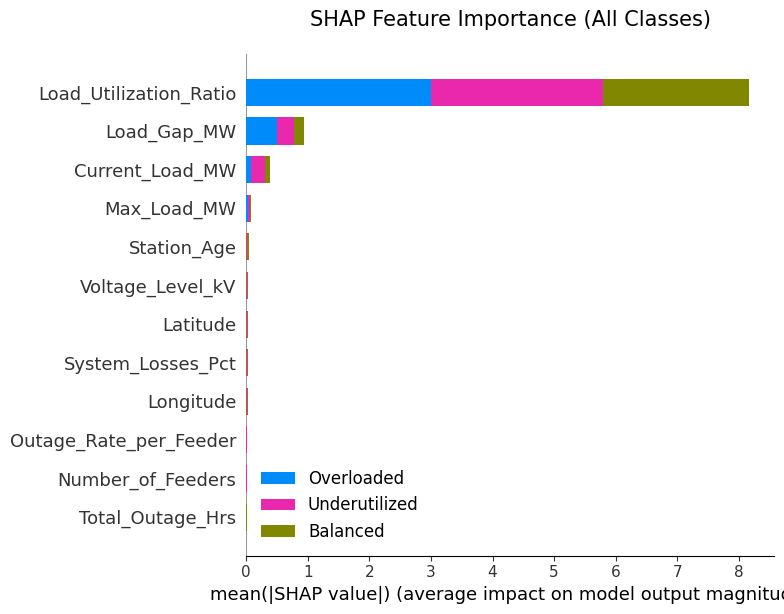

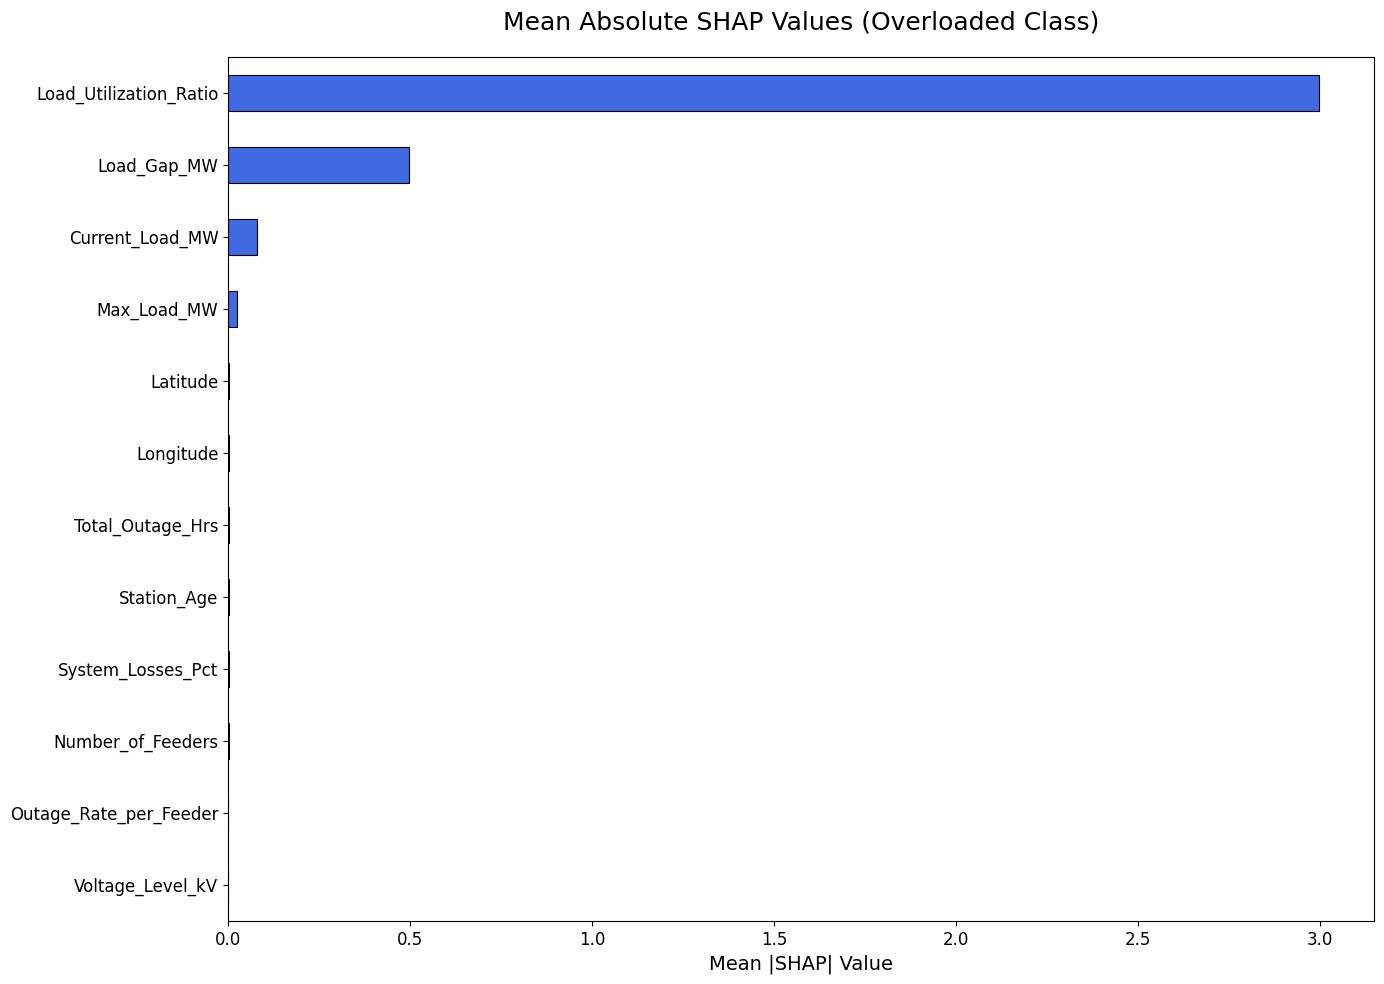

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

# ==================== Feature Importance Bar ====================
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  class_names=le.classes_, show=False)
plt.title("SHAP Feature Importance (All Classes)", fontsize=15, pad=20)
plt.tight_layout()

plt.show()





# ====================  Mean |SHAP| Bar ====================
plt.figure(figsize=(14, 10))
mean_abs = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
pd.Series(mean_abs, index=feature_cols).sort_values(ascending=True).plot(
    kind='barh', color='royalblue', edgecolor='black', linewidth=0.8)
plt.title("Mean Absolute SHAP Values (Overloaded Class)", fontsize=18, pad=20)
plt.xlabel("Mean |SHAP| Value", fontsize=14)
plt.tight_layout()

plt.show()



In [ ]:
!pip install stable-baselines3[extra] gymnasium shimmy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.5 MB/s eta 0:00:00


In [ ]:
# First install if needed
!pip install torch_geometric torch torchvision torchaudio -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split

# ====================== Build Graph ======================
G = nx.Graph()

for i, row in df.iterrows():
    features = [
        row['Load_Percentage']/100,
        row['Current_Load_MW']/row['Max_Load_MW'],
        row['Station_Age']/df['Station_Age'].max(),
        row['System_Losses_Pct']/20,
        row['Number_of_Feeders']/40,
        row['Load_Gap_MW']/row['Max_Load_MW']
    ]
    G.add_node(i, x=features, y=le.transform([row['Load_Category']])[0])

# Add edges based on proximity
for i in range(len(df)):
    for j in range(i+1, len(df)):
        dist = np.sqrt((df.loc[i,'Latitude']-df.loc[j,'Latitude'])**2 +
                       (df.loc[i,'Longitude']-df.loc[j,'Longitude'])**2)
        if dist < 0.7:  # ~70km
            G.add_edge(i, j, weight=1/dist)

# Convert to PyG Data
x = torch.tensor([G.nodes[i]['x'] for i in G.nodes()], dtype=torch.float)
y = torch.tensor([G.nodes[i]['y'] for i in G.nodes()], dtype=torch.long)
edge_index = torch.tensor(list(G.edges)).t().contiguous()

data = Data(x=x, edge_index=edge_index, y=y)

# ====================== GNN Model ======================
class GridGNN(torch.nn.Module):
    def __init__(self, num_features=6, hidden=64, num_classes=3):
        super().__init__()
        self.conv1 = GATConv(num_features, hidden, heads=4)
        self.conv2 = GATConv(hidden*4, hidden*2, heads=2)
        self.conv3 = GCNConv(hidden*2, hidden)
        self.fc1 = torch.nn.Linear(hidden, 32)
        self.fc2 = torch.nn.Linear(32, num_classes)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, data.batch if hasattr(data,'batch') else None)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model_gnn = GridGNN()
print("✅ GNN Model Created!")
print(model_gnn)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch_geometric/llm/utils/backend_utils.py:26: DeprecationWarning: `torch_geometric.distributed` has been deprecated since 2.7.0 and will no longer be maintained. For distributed training, refer to our tutorials on distributed training at https://pytorch-geometric.readthedocs.io/en/latest/tutorial/distributed.html or cuGraph examples at https://github.com/rapidsai/cugraph-gnn/tree/main/python/cugraph-pyg/cugraph_pyg/examples
  from torch_geometric.distributed import (
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.ex

✅ GNN Model Created!
GridGNN(
  (conv1): GATConv(6, 64, heads=4)
  (conv2): GATConv(256, 128, heads=2)
  (conv3): GCNConv(128, 64)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
